In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
plt.figure(figsize=(12, 12))
n_samples = 1500
random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state)

<Figure size 1200x1200 with 0 Axes>

Text(0.5, 1.0, 'Número incorreto de Clusters')

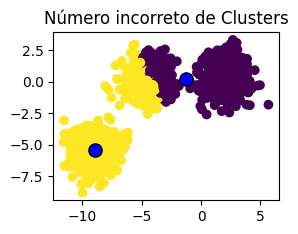

In [ ]:
# Incorrect number of clusters
y_pred = KMeans(n_clusters=2, random_state=random_state).fit_predict(X)
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
# Plot the centroids as a black/blue O- Calculate from kmeans++
from sklearn.cluster import kmeans_plusplus
kmeans = KMeans(init="k-means++", n_clusters=2, n_init=10)
kmeans.fit(X)
# Plot the centroids as a black/blue O
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker="o", s=90,
linewidths=1, color="b", edgecolor="black")
plt.title("Número incorreto de Clusters")

Text(0.5, 1.0, 'Distribuição anisotrópica de bolhas')

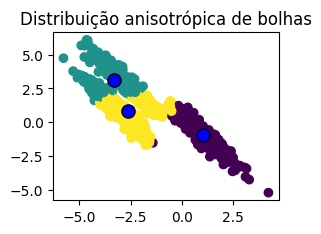

In [ ]:
# Anisotropicly distributed data
transformation = [[0.60834549,-0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)
y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_aniso)
plt.subplot(222)
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
# Plot the centroids as a black/blue O- Calculate from kmeans++
from sklearn.cluster import kmeans_plusplus
kmeans = KMeans(init="k-means++", n_clusters=3, n_init=10)
kmeans.fit(X_aniso)
# Plot the centroids as a black/blue O
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker="o", s=90,
linewidths=1, color="b", edgecolor="black")
plt.title("Distribuição anisotrópica de bolhas")

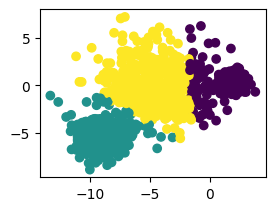

In [ ]:
# Different variance
X_varied, y_varied = make_blobs(n_samples=n_samples,
cluster_std=[1.0, 2.5, 0.5], random_state=random_state)
y_pred = KMeans(n_clusters=3,random_state=random_state).fit_predict(X_varied)
plt.subplot(223)
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)

Text(0.5, 1.0, 'Diferentes variâncias- Diferentes dispersões')

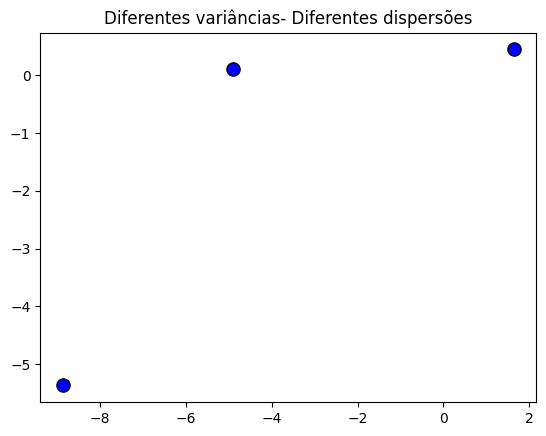

In [ ]:
# Plot the centroids as a black/blue O- Calculate from kmeans++
from sklearn.cluster import kmeans_plusplus
kmeans = KMeans(init="k-means++", n_clusters=3, n_init=10)
kmeans.fit(X_varied)
# Plot the centroids as a black/blue O
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker="o", s=90,
linewidths=1, color="b", edgecolor="black")
plt.title("Diferentes variâncias- Diferentes dispersões")

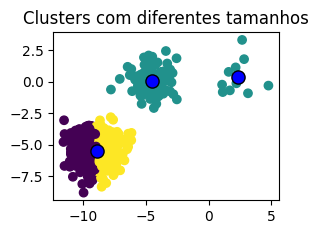

In [ ]:
# Unevenly sized blobs
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]))
#ou X_filtered, y = make_blobs(n_samples=[500,100,10], random_state=random_state)
y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_filtered)
plt.subplot(224)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
# Plot the centroids as a black/blue O- Calculate from kmeans++
from sklearn.cluster import kmeans_plusplus
kmeans = KMeans(init="k-means++", n_clusters=3, n_init=10)
kmeans.fit(X_filtered)
# Plot the centroids as a black/blue O
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker="o", s=90,
linewidths=1, color="b", edgecolor="black")
#plt.title("Unevenly Sized Blobs")
plt.title("Clusters com diferentes tamanhos")
plt.show()

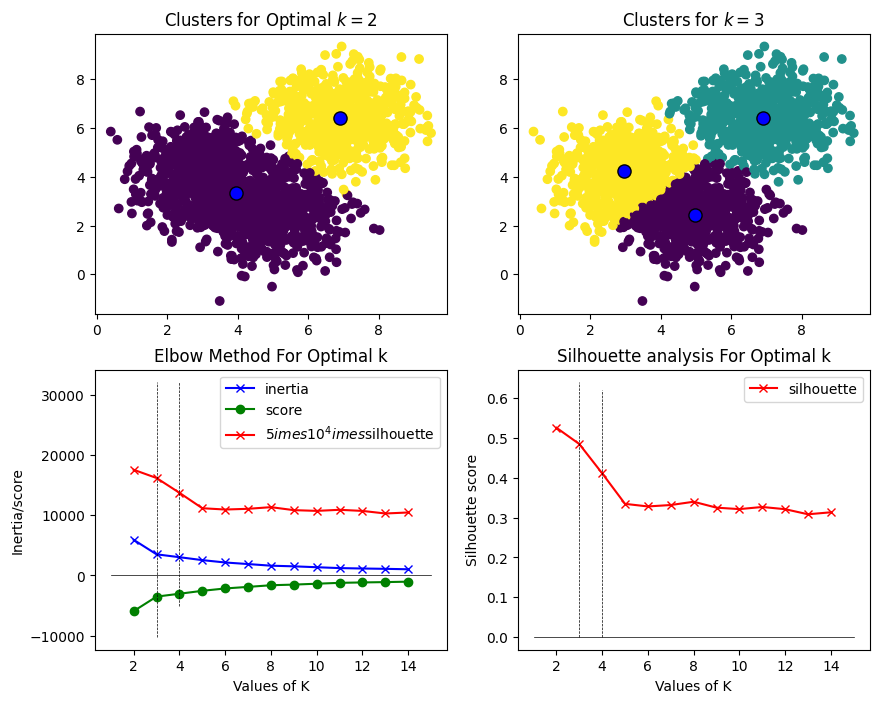

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

n_samples = 2000
random_state = 190

Kk = range(2,15) # Define Kk before using it
X, y = make_blobs(n_samples=n_samples, random_state=random_state) # Removed 'centers=Kk' as it's incorrect here

Sum_of_squared_distances = []
y_score1 = []
silhouette_avg = []

for num_clusters in Kk:
    kmeans = KMeans(n_clusters=num_clusters, n_init='auto', random_state=random_state)
    kmeans.fit(X)
    y_score = kmeans.score(X)
    y_score1 = np.append(y_score1,y_score)
    Sum_of_squared_distances.append(kmeans.inertia_)
    cluster_labels = kmeans.labels_
    if num_clusters >= 2:
        silhouette_avg.append(silhouette_score(X, cluster_labels))

plt.figure(figsize=(10, 8))

# Optimal K from silhouette_avg, ensuring K is within Kk bounds
K_optimal_idx = np.argmax(silhouette_avg)
K = Kk[K_optimal_idx]

kmeans = KMeans(init="k-means++", n_clusters=K, n_init='auto', random_state=random_state)
y_pred = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="o", s=90,
            linewidths=1, color="b", edgecolor="black")
plt.title("Clusters for Optimal $k=%i$" % K)

# Using K+1 for comparison
K_plus_1 = K + 1
# Ensure K_plus_1 is within the range of Kk for consistency if evaluating it
kmeans = KMeans(init="k-means++", n_clusters=K_plus_1, n_init='auto', random_state=random_state)
y_pred = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
plt.subplot(222)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="o", s=90,
            linewidths=1, color="b", edgecolor="black")
plt.title("Clusters for $k=%i$" % K_plus_1)

m = (abs(max(y_score1))/abs(min(silhouette_avg)))*10
sill = np.dot(m,silhouette_avg)

plt.subplot(223)
plt.plot(Kk, Sum_of_squared_distances,'bx-',label="inertia")
plt.plot(Kk, y_score1, 'go-',label="score")
plt.plot(Kk, sill,'rx-',label='$5\times10^4\times$silhouette')
xx = [3,3]
xx1 = [4,4]
yy = [-10200,32000]
yy1 = [-5000,32000]
plt.plot(xx, yy, c='black', linestyle="--",linewidth=0.5)
plt.plot(xx1, yy1, c='black', linestyle="--",linewidth=0.5)
plt.plot([1,15], [0,0], c='black', linestyle="-",linewidth=0.5)
plt.xlabel('Values of K')
plt.ylabel('Inertia/score')
plt.title('Elbow Method For Optimal k')
plt.legend()

plt.subplot(224)
plt.plot(Kk, silhouette_avg,'rx-',label="silhouette")
plt.xlabel('Values of K')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis For Optimal k')
yy = [0,0.64]
yy1 = [0,0.62]
plt.plot(xx, yy, c='black', linestyle="--",linewidth=0.5)
plt.plot(xx1, yy1, c='black', linestyle="--",linewidth=0.5)
plt.plot([1,15], [0,0], c='black', linestyle="-",linewidth=0.5)
plt.legend()

plt.show()